In [1]:
import pandas as pd
import numpy as np
from Preprocessing import CombinedPreprocessor
from RandomCV import RandomCV
from GroupKFoldCV import GroupKFoldCV
from SpatialPlusCV import SpatialPlusCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

from IPython.display import display

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.145905,0.539984,0.003726,0.018487
1,LR,TEST,0.255455,-0.419868,0.008399,0.094550
2,RF,CV,0.089814,0.825560,0.002351,0.010002
3,RF,TEST,0.277065,-0.680938,0.023974,0.284568
4,XGB,CV,0.094776,0.805372,0.003955,0.018634
5,XGB,TEST,0.269802,-0.589257,0.018119,0.220898


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.305985,-8.233395,0.224208,14.789966
1,LR,TEST,0.341138,-1.626450,0.066836,0.998879
2,RF,CV,0.176105,-1.199301,0.074064,2.507678
3,RF,TEST,0.250140,-0.384115,0.033360,0.363667
4,XGB,CV,0.181239,-1.192263,0.069693,2.267508
5,XGB,TEST,0.263446,-0.526417,0.028750,0.331721


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.174564,0.061419,0.053279,0.608739
1,LR,TEST,0.290559,-0.899096,0.054338,0.735652
2,RF,CV,0.122590,0.523655,0.043004,0.350731
3,RF,TEST,0.268615,-0.612113,0.044933,0.459830
4,XGB,CV,0.128824,0.471866,0.046961,0.405702
5,XGB,TEST,0.270462,-0.634139,0.045133,0.473713


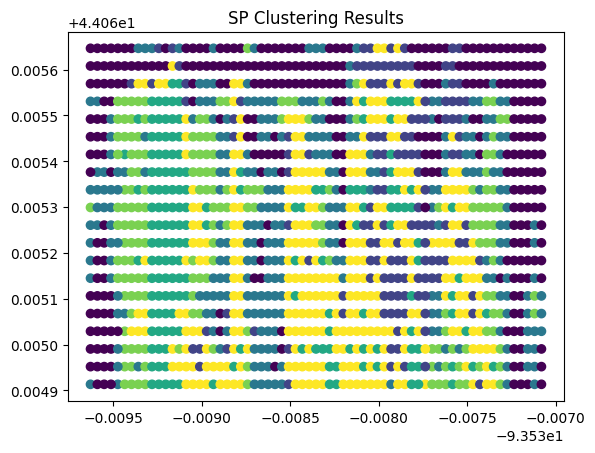

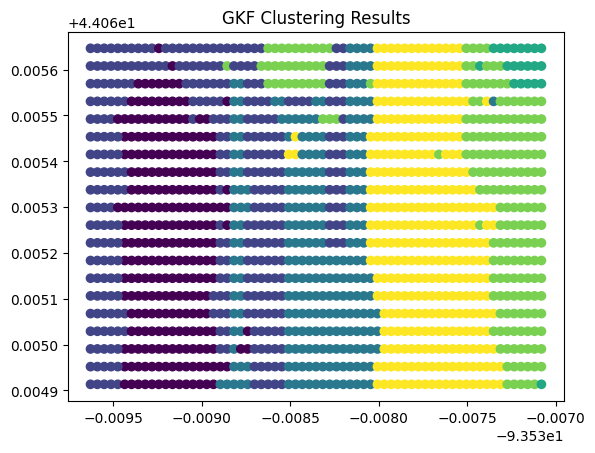

In [4]:
p = CombinedPreprocessor()

indices_6182020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_18_2020_New.csv")
indices_6232020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_23_2020_New.csv")
indices_6302020 = pd.read_csv("../Datasets/Indices_Combined/2020/June_30_2020_New.csv")
indices_7062020 = pd.read_csv("../Datasets/Indices_Combined/2020/July_6_2020_New.csv")
clusters_2020 = pd.read_csv("../Datasets/Clusters/2020_6group_all.csv")['CLUSTER_ID'].to_numpy()

X_train_validate, X_test, Y_train_validate, Y_test = p.transform([indices_6182020, indices_6232020, indices_6302020], indices_7062020)

random_validator = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6)
gkf_validator = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, clusters=clusters_2020, n_clusters=6)
sp_validator = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, n_clusters=6)
random_results = random_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
gkf_results = gkf_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)
sp_results = sp_validator.results(X_train_validate, X_test, Y_train_validate, Y_test)

display(random_results, gkf_results, sp_results)
sp_validator.display_clusters()
gkf_validator.display_clusters()


,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.119920,0.513028,0.003915,0.020171
1,LR,TEST,0.367629,-3.810385,0.095484,2.288384
2,RF,CV,0.092959,0.707307,0.003808,0.017122
3,RF,TEST,0.131379,0.419827,0.011810,0.105388
4,XGB,CV,0.095094,0.693500,0.005917,0.028909
5,XGB,TEST,0.140683,0.333177,0.014390,0.140158


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.194169,-1.282938,0.065458,1.532906
1,LR,TEST,0.402298,-4.828622,0.113852,3.145339
2,RF,CV,0.140777,-0.159333,0.025541,0.662990
3,RF,TEST,0.150453,0.209476,0.032749,0.378341
4,XGB,CV,0.155902,-0.370635,0.037360,0.646126
5,XGB,TEST,0.156600,0.155767,0.028208,0.310286


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.131252,0.364780,0.025774,0.222376
1,LR,TEST,0.362762,-3.542797,0.068170,1.685774
2,RF,CV,0.106080,0.585254,0.015926,0.122514
3,RF,TEST,0.142235,0.294574,0.030425,0.337997
4,XGB,CV,0.115176,0.511175,0.015093,0.130229
5,XGB,TEST,0.153527,0.199698,0.020767,0.215725


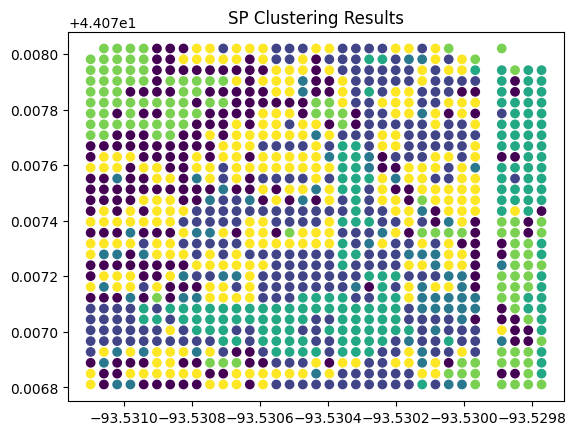

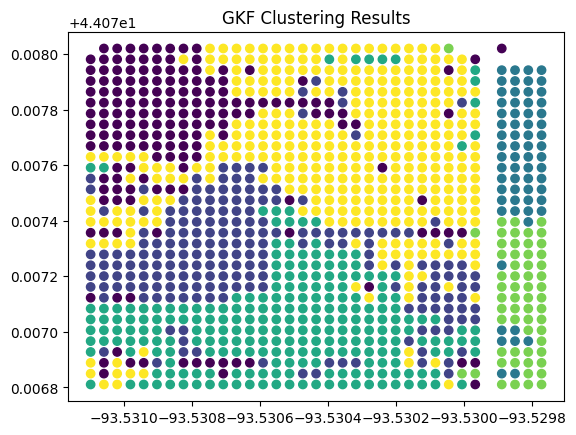

In [5]:
p1 = CombinedPreprocessor()

indices_6162021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_16_2021.csv")
indices_6222021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_22_2021.csv")
indices_6302021 = pd.read_csv("../Datasets/Indices_Combined/2021/June_30_2021.csv")
indices_7122021 = pd.read_csv("../Datasets/Indices_Combined/2021/July_12_2021.csv")
clusters_2021 = pd.read_csv("../Datasets/Clusters/2021_6group_all.csv")['CLUSTER_ID'].to_numpy()

X_train_validate1, X_test1, Y_train_validate1, Y_test1 = p1.transform([indices_6162021, indices_6222021, indices_6302021], indices_7122021)

random_validator1 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6)
gkf_validator1 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, clusters=clusters_2021, n_clusters=6)
sp_validator1 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, n_clusters=6)
random_results1 = random_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
gkf_results1 = gkf_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)
sp_results1 = sp_validator1.results(X_train_validate1, X_test1, Y_train_validate1, Y_test1)

display(random_results1, gkf_results1, sp_results1)
sp_validator1.display_clusters()
gkf_validator1.display_clusters()

,Random,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.133178,0.271276,0.016361,0.169002
1,LR,TEST,0.412581,-6.769833,0.083077,2.975318
2,RF,CV,0.102337,0.578340,0.014233,0.052506
3,RF,TEST,0.139880,0.139439,0.007175,0.089560
4,XGB,CV,0.105789,0.545677,0.012889,0.071503
5,XGB,TEST,0.138061,0.158826,0.010722,0.130320


,GroupKFold,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.203286,-1.635351,0.144610,1.381920
1,LR,TEST,0.367035,-5.206916,0.082350,2.437649
2,RF,CV,0.171724,-1.206281,0.086470,1.277604
3,RF,TEST,0.136976,0.175090,0.006538,0.078692
4,XGB,CV,0.185665,-1.595308,0.088271,1.357255
5,XGB,TEST,0.137404,0.171229,0.003631,0.043696


,Spatial+,TYPE,RMSE_AVG,R2_AVG,RMSE STD,R2 STD
0,LR,CV,0.159278,-0.554716,0.099382,0.983878
1,LR,TEST,0.421221,-6.968583,0.065031,2.526085
2,RF,CV,0.109069,0.217501,0.035053,0.290908
3,RF,TEST,0.140374,0.135276,0.002768,0.034170
4,XGB,CV,0.124421,-0.084903,0.035264,0.532176
5,XGB,TEST,0.143439,0.096013,0.005734,0.072814


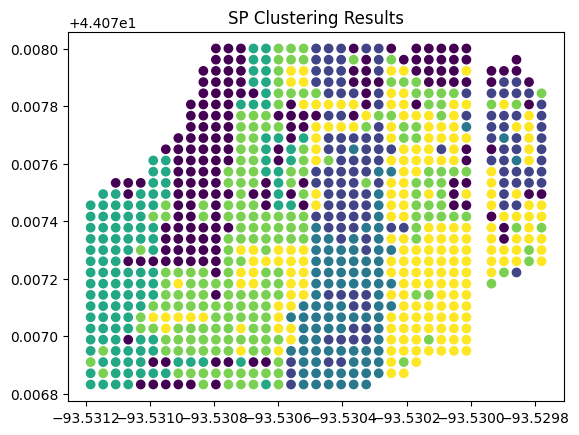

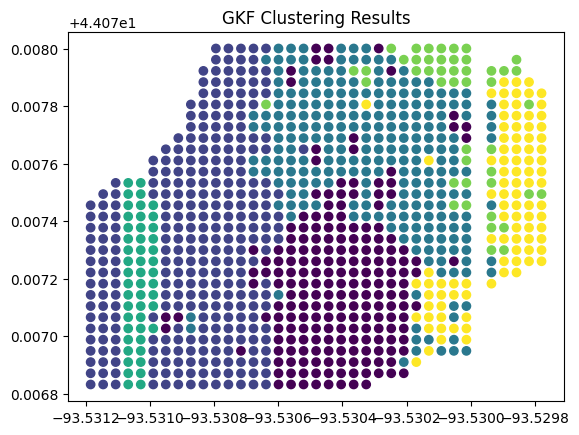

In [6]:
p2 = CombinedPreprocessor()

indices_6152022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_15_2022.csv")
indices_6232022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_23_2022.csv")
indices_6282022 = pd.read_csv("../Datasets/Indices_Combined/2022/June_28_2022.csv")
indices_7132022 = pd.read_csv("../Datasets/Indices_Combined/2022/July_13_2022.csv")
clusters_2022 = pd.read_csv("../Datasets/Clusters/2022_6group_all.csv")['CLUSTER_ID'].to_numpy()

X_train_validate2, X_test2, Y_train_validate2, Y_test2 = p2.transform([indices_6152022, indices_6232022, indices_6282022], indices_7132022)

random_validator2 = RandomCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6)
gkf_validator2 = GroupKFoldCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, clusters=clusters_2022, n_clusters=6)
sp_validator2 = SpatialPlusCV(models={'LR': LinearRegression(n_jobs=-1), 'RF': RandomForestRegressor(n_jobs=-1, random_state=41), 'XGB': XGBRegressor()}, n_folds=6, n_clusters=6)
random_results2 = random_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
gkf_results2 = gkf_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)
sp_results2 = sp_validator2.results(X_train_validate2, X_test2, Y_train_validate2, Y_test2)

display(random_results2, gkf_results2, sp_results2)
sp_validator2.display_clusters()
gkf_validator2.display_clusters()